In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib
%matplotlib inline

In [3]:
adata = sc.read('/data/work/07.3d/Result/Spateo/1023/all_batch_3d.h5ad')
adata

AnnData object with n_obs × n_vars = 457858 × 17887
    obs: 'area', 'x', 'y', 'region', 'n_counts', 'slices', 'batch', 'celltype', 'celltype_main', 'celltype_main_sub'
    uns: 'celltype_colors', 'celltype_main_colors', 'celltype_main_sub_colors', 'region_colors'
    obsm: '3d_align_spatial', 'Nonrigid_align_spatial', 'Rigid_align_spatial', 'X_umap', 'align_spatial', 'bbox', 'spatial'

In [ ]:

def RGB_to_Hex(rgb):
    RGB = rgb.split(',')            # 将RGB格式划分开来
    color = ''
    for i in RGB:
        num = int(i)
        # 将R、G、B分别转化为16进制拼接转换并大写  hex() 函数用于将10进制整数转换成16进制，以字符串形式表示
        color += str(hex(num))[-2:].replace('x', '0').lower()
    # print(color)
    return color


In [10]:
def read_img(img_path):
    img = cv2.imread(img_path)
    img = img[:,:,::-1] 	# transform image to rgb
    print(f'dtype: {img.dtype}, shape: {img.shape}, min: {np.min(img)}, max: {np.max(img)}')
    return img

In [2]:
dic = {
    '1' : '/data/input/Files/ChipManualAnn/20231123ajusted/01_02_A02187B2_adj.png',
    '2' : '/data/input/Files/ChipManualAnn/20231123ajusted/01_02_A02187B2_adj.png',
    '3' : '/data/input/Files/ChipManualAnn/20231123ajusted/03_04_A02187B1_adj.png',
    '4' : '/data/input/Files/ChipManualAnn/20231123ajusted/03_04_A02187B1_adj.png',
    '5' : '/data/input/Files/ChipManualAnn/20231123ajusted/05_06_A02187A5_adj.png',
    '6' : '/data/input/Files/ChipManualAnn/20231123ajusted/05_06_A02187A5_adj.png',
    '7' : '/data/input/Files/ChipManualAnn/20231123ajusted/07_08_B02111B5_adj.png',
    '8' : '/data/input/Files/ChipManualAnn/20231123ajusted/07_08_B02111B5_adj.png',
    '9' : '/data/input/Files/ChipManualAnn/20231123ajusted/09_10_A02187A6_adj.png',
    '10' : '/data/input/Files/ChipManualAnn/20231123ajusted/09_10_A02187A6_adj.png',
    '11' : '/data/input/Files/ChipManualAnn/20231123ajusted/11_12_B02111B6_adj.png',
    '12' : '/data/input/Files/ChipManualAnn/20231123ajusted/11_12_B02111B6_adj.png',
    '13' : '/data/input/Files/ChipManualAnn/20231123ajusted/13_14_B02111C1_adj.png',
    '14' : '/data/input/Files/ChipManualAnn/20231123ajusted/13_14_B02111C1_adj.png',
    '15' : '/data/input/Files/ChipManualAnn/20231123ajusted/15_16_B02111C5_adj.png',
    '16' : '/data/input/Files/ChipManualAnn/20231123ajusted/15_16_B02111C5_adj.png',
    '17' : '/data/input/Files/ChipManualAnn/20231123ajusted/17_18_A02187A3_adj.png',
    '18' : '/data/input/Files/ChipManualAnn/20231123ajusted/17_18_A02187A3_adj.png',
    '19' : '/data/input/Files/ChipManualAnn/20231123ajusted/19_20_A02187A2_adj_anno.png',
    '20' : '/data/input/Files/ChipManualAnn/20231123ajusted/19_20_A02187A2_adj_anno.png',
    '21' : '/data/input/Files/ChipManualAnn/20231123ajusted/21_22_A02187D1_adj_anno.png',
    '22' : '/data/input/Files/ChipManualAnn/20231123ajusted/21_22_A02187D1_adj_anno.png',
    '23' : '/data/input/Files/ChipManualAnn/20231123ajusted/23_24_A02187D2_adj_anno.png',
    '24' : '/data/input/Files/ChipManualAnn/20231123ajusted/23_24_A02187D2_adj_anno.png',
    '25' : '/data/input/Files/ChipManualAnn/20231123ajusted/25_26_A02187C6_adj.png',
    '26' : '/data/input/Files/ChipManualAnn/20231123ajusted/25_26_A02187C6_adj.png',
    '27' : '/data/input/Files/ChipManualAnn/20231123ajusted/27_28_A02187D3_adj_anno.png',
    '28' : '/data/input/Files/ChipManualAnn/20231123ajusted/27_28_A02187D3_adj_anno.png',
    '29' : '/data/input/Files/ChipManualAnn/20231123ajusted/29_30_A02184F6_adj_anno.png',
    '30' : '/data/input/Files/ChipManualAnn/20231123ajusted/29_30_A02184F6_adj_anno.png',
    '31' : '/data/input/Files/ChipManualAnn/20231123ajusted/31_32_A02184F4_adj_anno.png',
    '32' : '/data/input/Files/ChipManualAnn/20231123ajusted/31_32_A02184F4_adj_anno.png',
    '33' : '/data/input/Files/ChipManualAnn/20231123ajusted/33_34_A02185A3_adj_anno.png',
    '34' : '/data/input/Files/ChipManualAnn/20231123ajusted/33_34_A02185A3_adj_anno.png',
    '35' : '/data/input/Files/ChipManualAnn/20231123ajusted/35_36_A02185A2_adj_anno.png',
    '36' : '/data/input/Files/ChipManualAnn/20231123ajusted/35_36_A02185A2_adj_anno.png',
    '37' : '/data/input/Files/ChipManualAnn/20231123ajusted/37_38_A02185E6_adj_anno.png',
    '38' : '/data/input/Files/ChipManualAnn/20231123ajusted/37_38_A02185E6_adj_anno.png',
    '39' : '/data/input/Files/ChipManualAnn/20231123ajusted/39_40_A02187A4_adj_anno.png',
    '40' : '/data/input/Files/ChipManualAnn/20231123ajusted/39_40_A02187A4_adj_anno.png',
}

In [18]:
# set(adata.obs['slices'])

In [7]:
anno = []
for i in range(1,41):
    i = str(i)
    img = read_img(dic[i])
    temp = sc.read('/data/work/02.QC/Cellbin/' + str(i) + '.h5ad')
    
    x = [int(i) for i in temp.obs['x']]
    y = [int(i) for i in temp.obs['y']]
    # 
    for i in range(len(x)):
        # print(x[i],y[i])
        # print(img[x[i]][y[i]])
        temp = (',').join([str(i) for i in img[x[i]][y[i]]])
        colo = RGB_to_Hex(temp)
        # if colo == '787878':
        #     print(i)
        try:
            region = csv[csv['color']==colo]['Brain_Region'].tolist()[0].replace(' ','_')
        except:
            # print(colo)
            region = 'NAN'
        anno.append(region)
        # break
    
    # break

dtype: uint8, shape: (18149, 22473, 3), min: 0, max: 255
dtype: uint8, shape: (18149, 22473, 3), min: 0, max: 255
dtype: uint8, shape: (15851, 23407, 3), min: 0, max: 255
dtype: uint8, shape: (15851, 23407, 3), min: 0, max: 255
dtype: uint8, shape: (20497, 24141, 3), min: 0, max: 254
dtype: uint8, shape: (20497, 24141, 3), min: 0, max: 254
dtype: uint8, shape: (21540, 22809, 3), min: 0, max: 255
dtype: uint8, shape: (21540, 22809, 3), min: 0, max: 255
dtype: uint8, shape: (21380, 25982, 3), min: 0, max: 255
dtype: uint8, shape: (21380, 25982, 3), min: 0, max: 255
dtype: uint8, shape: (20995, 21773, 3), min: 0, max: 255
dtype: uint8, shape: (20995, 21773, 3), min: 0, max: 255
dtype: uint8, shape: (17873, 23334, 3), min: 0, max: 255
dtype: uint8, shape: (17873, 23334, 3), min: 0, max: 255
dtype: uint8, shape: (18837, 24550, 3), min: 0, max: 255
dtype: uint8, shape: (18837, 24550, 3), min: 0, max: 255
dtype: uint8, shape: (18129, 25713, 3), min: 0, max: 255
dtype: uint8, shape: (18129, 25

In [ ]:
csv = pd.read_excel('/data/work/05.Ann/Script/Augment/Batch/brainRegion-20231124.xlsx')

spot_color = {}
for i in range(44):
    # print(csv['Brain_Region'][i])
    Brain_Region = csv['Brain_Region'][i].replace(' ','_')
    spot_color[Brain_Region] = '#'+str(csv['color'][i])
spot_color['NAN'] = 'BLACK'
spot_color['NA'] = 'white'

In [14]:
temp = sc.read('/data/work/02.QC/Cellbin/' + str(1) + '.h5ad')
temp

AnnData object with n_obs × n_vars = 2034 × 8901
    obs: 'area', 'x', 'y', 'region', 'n_counts'
    var: 'n_cells'
    uns: 'region_colors', 'spatial'
    obsm: 'bbox', 'spatial'

In [15]:
temp.obs

,area,x,y,region,n_counts
2,2235,6679.653244,10554.933781,meninges,523
5,2120,5548.587264,7334.187264,meninges,406
7,1321,5592.755488,6688.466313,meninges,733
9,2022,7745.028190,18044.226014,spain_cord,238
10,2244,6769.467469,6449.541889,cerebral,2793
...,...,...,...,...,...
30572,1506,6345.753652,9543.514608,meninges,257
31282,451,7296.011086,13126.184035,meninges,217
31353,1872,7417.714744,14239.869124,meninges,269
31594,1332,7423.464715,14015.580330,meninges,224


In [13]:
# anno

In [8]:
len(anno)

457858

In [9]:
adata

AnnData object with n_obs × n_vars = 457858 × 17887
    obs: 'area', 'x', 'y', 'region', 'n_counts', 'slices', 'batch', 'celltype', 'celltype_main', 'celltype_main_sub'
    uns: 'celltype_colors', 'celltype_main_colors', 'celltype_main_sub_colors', 'region_colors'
    obsm: '3d_align_spatial', 'Nonrigid_align_spatial', 'Rigid_align_spatial', 'X_umap', 'align_spatial', 'bbox', 'spatial'

In [10]:
adata.obs.region = anno

In [11]:
set(adata.obs.region)

{'NAN'}

In [60]:
adata.write('/data/work/07.3d/Result/Spateo/1127/1127.h5ad')

In [9]:
# adata.obs['x'],adata.obs['y']

In [17]:
csv['color'] = csv['color'].astype(str)
# csv['color']

In [18]:
anno = []
for i in range(len(x)):
    # print(x[i],y[i])
    # print(img[x[i]][y[i]])
    temp = (',').join([str(i) for i in img[x[i]][y[i]]])
    colo = RGB_to_Hex(temp)
    # if colo == '787878':
    #     print(i)
    try:
        region = csv[csv['color']==colo]['Brain_Region'].tolist()[0].replace(' ','_')
    except:
        # print(colo)
        region = 'NAN'
    anno.append(region)
    # break

In [19]:
adata.obs['region'] = anno

In [20]:
adata.obs

,area,x,y,region
2,2235,6679.653244,10554.933781,meninges
5,2120,5548.587264,7334.187264,meninges
7,1321,5592.755488,6688.466313,meninges
9,2022,7745.028190,18044.226014,spain_cord
10,2244,6769.467469,6449.541889,cerebral
...,...,...,...,...
32912,694,6781.211816,15562.422190,meninges
32977,932,6795.344421,10123.756438,meninges
33000,264,6070.909091,14763.155303,meninges
33111,1119,7231.050045,14957.672029,meninges


In [21]:
adata

AnnData object with n_obs × n_vars = 7675 × 20189
    obs: 'area', 'x', 'y', 'region'
    uns: 'spatial'
    obsm: 'bbox', 'spatial'

In [22]:
adata.obsm['spatial']

array([[1552.65324385, 4868.93378076],
       [ 421.58726415, 1648.18726415],
       [ 465.75548827, 1002.4663134 ],
       ...,
       [ 943.90909091, 9077.15530303],
       [2104.05004468, 9271.6720286 ],
       [2112.81937912, 7533.04421449]])

In [23]:
# sc.pl.scatter?

In [24]:
spot_color

{'cerebellum': '#7f3838',
 'cerebral': '#1d19e1',
 'choroid_plexus': '#383f7f',
 'columna_motoria_spinalis': '#847fc6',
 'commissura_interbulbaris': '#beaa00',
 'commissura_posterior': '#be7000',
 'corpus_geniculatum_laterale': '#35a373',
 'diencephalon': '#c34012',
 'dorsal_sac': '#787eff',
 'ependyma': '#dbea77',
 'fasciculus_retroflexus': '#0d300c',
 'ganglia_habenulae': '#be0400',
 'griseum_centrale_rhombencephali': '#387f76',
 'hypothalami_nucleus': '#6f07be',
 'inferior_rhombencephalic_reticular_centres': '#b816b6',
 'lobus_vagi': '#5316b8',
 'medulla_oblongata': '#8b5c1f',
 'meninges': '#7cfef0',
 'middle_superior_rhombencephalic_reticular_centre': '#16b8b6',
 'motor_nucleus_of_V': '#4447b0',
 'motor_nucleus_of_Ⅶ': '#9a44b0',
 'nervus_pinealis': '#fdff78',
 'neurohypophysis': '#f56b46',
 'nucleus_cerebelli': '#dc84a3',
 'nucleus_dorsalis_areae_octavolateralis': '#1df0f2',
 'nucleus_intermediu_areae_octavolateralis': '#6eb22b',
 'nucleus_interpeduncularis': '#9fb816',
 'nucleus_o

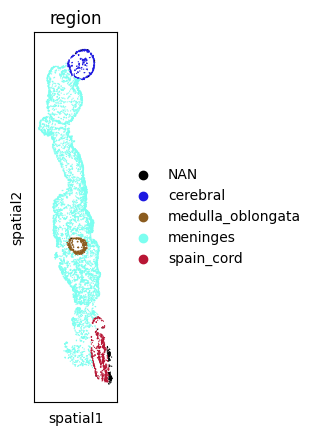

In [25]:
sc.pl.spatial(adata,color = 'region',spot_size=50,palette = spot_color)

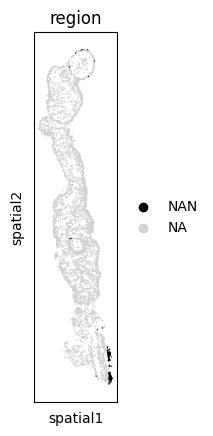

In [26]:
sc.pl.spatial(adata,color = 'region', groups='NAN',spot_size=50,palette = spot_color)

In [27]:
adata

AnnData object with n_obs × n_vars = 7675 × 20189
    obs: 'area', 'x', 'y', 'region'
    uns: 'spatial', 'region_colors'
    obsm: 'bbox', 'spatial'

In [28]:
adata = adata[adata.obs['region']!='NAN']
adata

View of AnnData object with n_obs × n_vars = 7517 × 20189
    obs: 'area', 'x', 'y', 'region'
    uns: 'spatial', 'region_colors'
    obsm: 'bbox', 'spatial'

/opt/software/python/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


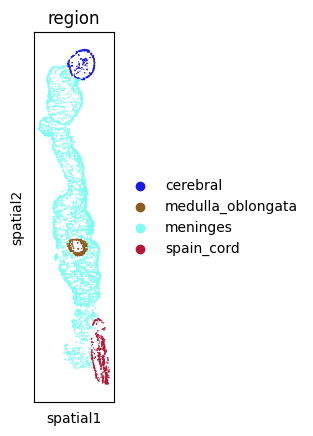

In [29]:
sc.pl.spatial(adata,color = 'region',spot_size=50,palette = spot_color)

In [30]:
adata.write('/data/work/05.Ann/Cellbin/Augment/1/0913/1.h5ad')

In [ ]:
import scanpy as sc
adata = sc.read('/data/work/05.Ann/Cellbin/Augment/1/0913/1.h5ad')
adata.X

<7517x20189 sparse matrix of type '<class 'numpy.uint16'>'
	with 568620 stored elements in Compressed Sparse Row format>

In [2]:
adata.X = adata.X.astype(int)
adata.X

<7517x20189 sparse matrix of type '<class 'numpy.int64'>'
	with 568620 stored elements in Compressed Sparse Row format>

In [3]:
adata.write('/data/work/05.Ann/Cellbin/Augment/1/0913/1.h5ad')